In [36]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np 
from image_decoder import ImageDecoder
from architectures import DetHead
import torch.nn.functional as F 

# add_label_to_video

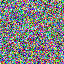

In [101]:
T = 1 
H = 64
W = 64
C = 3

video = np.random.randint(0,255,(T, H, W, C),dtype=np.uint8)
font = ImageFont.load_default()

frame = Image.fromarray(video[0])
frame 

In [102]:
draw = ImageDraw.Draw(frame, "RGBA")
draw 

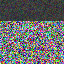

In [ ]:
draw.rectangle([0,0, W, 20], fill=(40, 40, 40, 200))    # location, color RGBA
frame

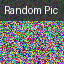

In [ ]:
draw.text((4, 4), text="Random Pic", fill=(255, 255, 255), font = font) # location, text, RGB color, font
frame

# Getting Rollout 

In [3]:
from eb_jepa.datasets.moving_mnist import MovingMNISTDet
from torch.utils.data import DataLoader

train_data = MovingMNISTDet(split="train")
train_dl = DataLoader(train_data, batch_size=32, shuffle=False,drop_last=True)

In [4]:
for batch in train_dl: 
    x = batch["video"]
    print(x.shape)
    break

torch.Size([32, 1, 10, 64, 64])


In [5]:
import torch 
from architectures import ResNet5

D_OBS = 1  # input channels (gray scale) 
H_ENC = 32 # hidden dim in encoder 
D_STC = 16 # represenation dim (encoder output channels) 
H_PRE = 32   # hidden dim in predictor

encoder = ResNet5(in_d=D_OBS, h_d=H_ENC, out_d= D_STC)
with torch.no_grad(): 
    x_jepa  = encoder(x)
    print(x_jepa.shape)

torch.Size([32, 16, 10, 64, 64])


In [6]:
T = x.shape[2]
print(T)

10


In [7]:
from architectures import ResUNet, StateOnlyPredictor, Projector
from losses import VCLoss, SquareLossSeq
from jepa import JEPA 

predictor_net = ResUNet(2 * D_STC, H_PRE, D_STC)       
predictor     = StateOnlyPredictor(predictor_net, context_length=2)


projector = Projector(f"{D_STC}-{D_STC*4}-{D_STC*4}")   # "16-64-64"


regularizer = VCLoss(std_coeff=10.0, cov_coeff=100.0, proj=projector)  
pred_loss   = SquareLossSeq(projector)                                  

# --- JEPA: ties everything together ---
jepa = JEPA(encoder, encoder, predictor, regularizer, pred_loss)

In [8]:
preds,_ = jepa.unroll(
    x, 
    actions = None,
    nsteps = T - 2, 
    unroll_mode= "parallel",
    compute_loss=False,
    return_all_steps=True
)

In [9]:
print(len(preds))
print(preds[0].shape)

8
torch.Size([32, 16, 8, 64, 64])


# Rollout Pixel Reconstruction 

In [10]:
rollout = x_jepa[:, :, 1:].clone()
print(rollout.shape)
print(len(preds))

for t in range(1, T - 1): 
    rollout[:, :, t:] = preds[t - 1][:, :, t - 1 :]

print(rollout.shape)

torch.Size([32, 16, 9, 64, 64])
8


torch.Size([32, 16, 9, 64, 64])


In [11]:
pixel_decoder = ImageDecoder(D_STC, D_OBS)
rollout_reconstruction = pixel_decoder(rollout)
print(rollout_reconstruction.shape)

torch.Size([32, 1, 9, 64, 64])


# Rollout Detection 

In [12]:
detection_head = DetHead(D_STC, H_PRE, D_OBS)

In [13]:
# Location and predictions overlaid over rollout as blue heatmap

loc_prediction = detection_head(rollout)
print(loc_prediction.shape) # values between 0-1 


torch.Size([32, 9, 8, 8])


# Overlay 

In [14]:
loc_prediction = F.interpolate(loc_prediction, (x.shape[-2], x.shape[-1]), mode = "nearest")
print(loc_prediction.shape)


# The purpose of this operation is Color Coding for Visualization.

from einops import rearrange, repeat
loc_prediction = repeat(loc_prediction, "b t h w -> b c t h w", c=3).clone()
loc_prediction[:, :2].fill_(0)
print(loc_prediction.shape) # Blue is left to be loc_prediction. 

torch.Size([32, 9, 64, 64])
torch.Size([32, 3, 9, 64, 64])


In [15]:
detection_overlay = 0.2 * rollout_reconstruction + 0.8 * loc_prediction 
                        # (32, 1, 9, 64, 64)        # (32, 3, 9, 64, 64)
print(detection_overlay.shape)

torch.Size([32, 3, 9, 64, 64])


# Get GT 

In [16]:
gt = x[:, :, 1:]

# Scale and Convert to uint8

In [ ]:
def scale_and_convert_to_uint8(tensor): 
    tensor = F.interpolate(tensor, (100, 100), mode="bilinear") # setting the stage for 100x100 image
    if tensor.shape[0] == 1:    # make gt and rollout_reconstruciton 3D 
        # tensor is a video with dim : (C, T, H, W) ; it's not a batch. 
        tensor = tensor.repeat(3, 1, 1, 1)
    
    # Since (gt, rollout_reconstruction, and detection_overlay) values is between 0-1, 
    tensor = torch.clamp(tensor * 255, 0, 255).to(torch.uint8)  # we unnormalize it. 
    tensor = rearrange(tensor, "c t h w -> t h w c").cpu().numpy()  # from torch tensors to numpy arrays. 
    return tensor 

# visualize_videos

In [18]:
rows = [gt, rollout_reconstruction, detection_overlay]
print(gt.shape)
print(rollout_reconstruction.shape)
print(detection_overlay.shape)

labels = ["Ground truth", "predicted rollout", "Digit detections"]

torch.Size([32, 1, 9, 64, 64])
torch.Size([32, 1, 9, 64, 64])
torch.Size([32, 3, 9, 64, 64])


In [ ]:
from eval import add_label_to_video
import numpy as np 

num_samples = 16 

viz_videos = []
for b in range(num_samples): 
    videos = [row[b] for row in rows]   # rows = [gt, rollout_reconstruction, detection_overlay]
    videos = [scale_and_convert_to_uint8(video) for video in videos]
    videos = [
        add_label_to_video(video, label) for video, label in zip(videos, labels)
    ]
    videos = [video.transpose(0, 3, 1, 2) for video in videos]
    viz_videos.append(np.concatenate(videos, axis=2)) # (T, C, 3*H, W)

viz_videos  # a list of tall frames of gt, predicted rollout, Digit detection, that is accepted by wandb mp4 

[array([[[[ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
          ...,
          [  0,   0,   0, ...,   0,   0,   0],
          [  0,   0,   0, ...,   0,   0,   0],
          [  0,   0,   0, ...,   0,   0,   0]],
 
         [[ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
          ...,
          [  0,   0,   0, ...,   0,   0,   0],
          [  0,   0,   0, ...,   0,   0,   0],
          [  0,   0,   0, ...,   0,   0,   0]],
 
         [[ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
          ...,
          [102, 102, 102, ..., 101, 101, 101],
          [102, 101, 101, ..., 101, 101, 101],
          [102, 101, 101, ..., 102, 102, 101]]],
 
 
        [[[ 31,  31,  31, ...,  31,  31,  31],
          [ 31,  31,  31, ...,  31,  31,  31],
   

# validation_loop

In [138]:
from eb_jepa.datasets.moving_mnist import MovingMNISTDet

val_ds = MovingMNISTDet(split="val")
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, drop_last=True)
batch = next(iter(val_loader))
print(batch["video"].shape)
print(batch["digit_location"].shape)

torch.Size([32, 1, 10, 64, 64])
torch.Size([32, 10, 8, 8])


In [ ]:
import collections 

jepa.eval()
detection_head.eval()
pixel_decoder.eval()

metrics = collections.defaultdict(list)

ImageDecoder(
  (net): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [151]:
detection_head(torch.randn(32,16,10,64,64)).shape

torch.Size([32, 10, 8, 8])